## Lab Week 9 - Lotka-Volterra Model
---
### Simulasi dan Pemodelan Predator-Prey

- Nama: Faaid Sakhaa
- NIM: 24/539398/TK/59820
- Kelas: Teknologi Informasi

Notebook ini mengerjakan deliverable:
1. Time-series prey dan predator
2. Phase portrait dengan titik ekuilibrium ditandai
3. Parameter sweep (3 set) dan perbandingan amplitudo osilasi

Model dasar:
$$\frac{dx}{dt} = \alpha x - \beta x y$$
$$\frac{dy}{dt} = \delta x y - \gamma y$$

Penjelasan model dasar:
| Simbol | Makna |
|---|---|
| $x(t)$ | Populasi prey (mangsa) pada waktu $t$ |
| $y(t)$ | Populasi predator pada waktu $t$ |
| $\alpha$ | Laju pertumbuhan alami prey |
| $\beta$ | Intensitas interaksi predasi (pertemuan prey-predator) |
| $\delta$ | Efisiensi konversi hasil predasi menjadi pertumbuhan predator |
| $\gamma$ | Laju kematian alami predator |

Interpretasi tiap suku:
- $+\alpha x$: prey bertambah karena reproduksi alami.
- $-\beta xy$: prey berkurang karena dimangsa predator.
- $+\delta xy$: predator bertambah karena ketersediaan makanan (prey).
- $-\gamma y$: predator berkurang karena kematian alami.


### 1. Import Library dan Definisi Fungsi
Mengimpor `numpy` dan `matplotlib`, lalu membuat fungsi model Lotka-Volterra serta integrator RK4 untuk simulasi numerik.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def lotka_volterra_rhs(t, state, alpha, beta, delta, gamma, H=0.0):
    """Lotka-Volterra RHS with optional prey harvesting term -H."""
    x, y = state
    dx = alpha * x - beta * x * y - H
    dy = delta * x * y - gamma * y
    return np.array([dx, dy], dtype=float)

def rk4_integrate(rhs, y0, t, **params):
    y = np.zeros((len(t), len(y0)), dtype=float)
    y[0] = y0
    dt = t[1] - t[0]

    for i in range(len(t) - 1):
        yi = y[i]
        ti = t[i]
        k1 = rhs(ti, yi, **params)
        k2 = rhs(ti + 0.5 * dt, yi + 0.5 * dt * k1, **params)
        k3 = rhs(ti + 0.5 * dt, yi + 0.5 * dt * k2, **params)
        k4 = rhs(ti + dt, yi + dt * k3, **params)
        y[i + 1] = yi + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        y[i + 1] = np.maximum(y[i + 1], 0.0)
    return y

def coexistence_equilibrium(alpha, beta, delta, gamma, H=0.0):
    x_star = gamma / delta
    y_star = (alpha * x_star - H) / (beta * x_star)
    return x_star, y_star


### 2. Setup Parameter dan Simulasi Dasar
Mendefinisikan 3 set parameter, memilih kondisi awal yang sama dan tidak tepat berada pada titik ekuilibrium, lalu menjalankan simulasi untuk tiap set.


In [2]:
# Suggested parameter sets from the assignment slide
parameter_sets = [
    {'name': 'Set 1', 'alpha': 1.0, 'beta': 0.10, 'delta': 0.075, 'gamma': 1.5},
    {'name': 'Set 2', 'alpha': 0.5, 'beta': 0.10, 'delta': 0.075, 'gamma': 1.5},
    {'name': 'Set 3', 'alpha': 1.0, 'beta': 0.05, 'delta': 0.075, 'gamma': 1.5},
]

# The shared initial condition is chosen away from the equilibrium points
# so each parameter set displays its own transient and oscillatory behavior.
x0, y0 = 30.0, 8.0
t_end, dt = 200.0, 0.05
t = np.arange(0.0, t_end + dt, dt)

results = {}
equilibrium_rows = []
for p in parameter_sets:
    params = {k: v for k, v in p.items() if k != 'name'}
    sol = rk4_integrate(lotka_volterra_rhs, np.array([x0, y0]), t, **params)
    results[p['name']] = sol
    x_star_i, y_star_i = coexistence_equilibrium(**params)
    equilibrium_rows.append((p['name'], x_star_i, y_star_i))

set1 = parameter_sets[0]
sol1 = results['Set 1']
x1, y1 = sol1[:, 0], sol1[:, 1]

x_star, y_star = coexistence_equilibrium(**{k: v for k, v in set1.items() if k != 'name'})
print('Non-trivial equilibria for all parameter sets:')
for name, x_star_i, y_star_i in equilibrium_rows:
    print(f"{name:5s} | x* = {x_star_i:6.3f} | y* = {y_star_i:6.3f}")


Non-trivial equilibria for all parameter sets:
Set 1 | x* = 20.000 | y* = 10.000
Set 2 | x* = 20.000 | y* =  5.000
Set 3 | x* = 20.000 | y* = 20.000


### 3. Visualisasi Time-Series
Menampilkan grafik populasi prey dan predator terhadap waktu untuk Set 1 sesuai deliverable time-series.


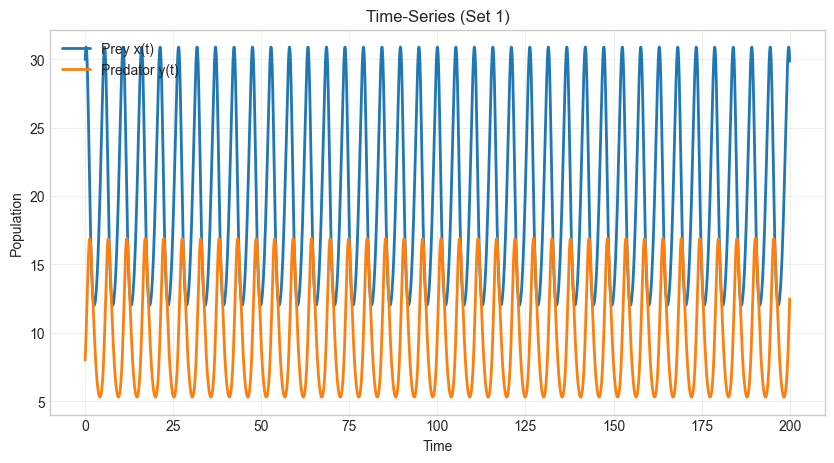

In [3]:
# 1) Time-series plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, x1, label='Prey x(t)', linewidth=2)
ax.plot(t, y1, label='Predator y(t)', linewidth=2)
ax.set_title('Time-Series (Set 1)')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


### 4. Visualisasi Phase Portrait
Memplot lintasan fase `x` vs `y` untuk Set 1 dan menandai titik ekuilibrium agar dinamika sistem mudah dianalisis.


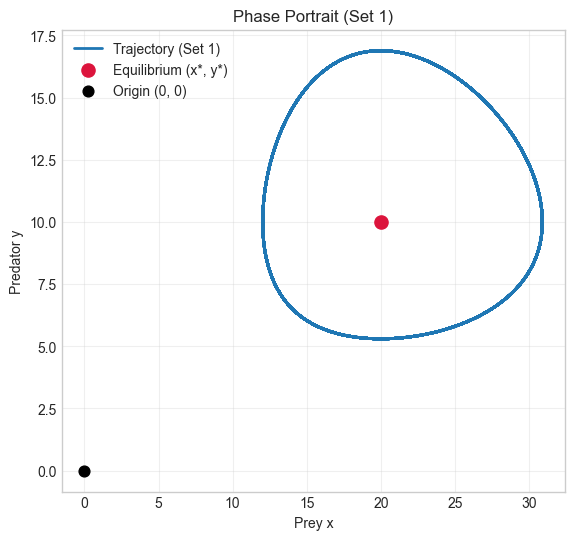

In [4]:
# 2) Phase portrait + equilibrium
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(x1, y1, color='tab:blue', linewidth=2, label='Trajectory (Set 1)')
ax.scatter([x_star], [y_star], s=90, color='crimson', label='Equilibrium (x*, y*)', zorder=4)
ax.scatter([0], [0], s=60, color='black', label='Origin (0, 0)', zorder=4)
ax.set_title('Phase Portrait (Set 1)')
ax.set_xlabel('Prey x')
ax.set_ylabel('Predator y')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


### 5. Parameter Sweep Tiga Set
Membandingkan hasil simulasi tiga set parameter pada grafik prey dan predator untuk melihat pengaruh perubahan parameter.


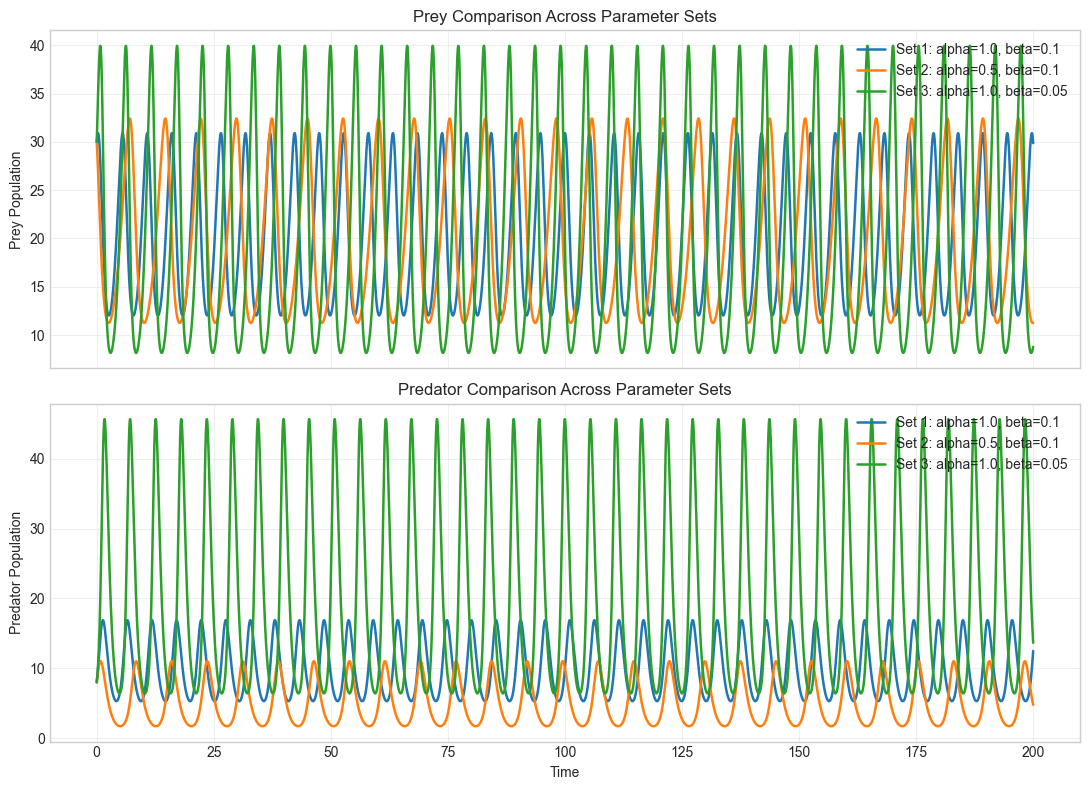

In [5]:
# 3) Parameter sweep: compare oscillations across 3 sets
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for p in parameter_sets:
    name = p['name']
    sol = results[name]
    label = f"{name}: alpha={p['alpha']}, beta={p['beta']}"
    ax1.plot(t, sol[:, 0], linewidth=1.8, label=label)
    ax2.plot(t, sol[:, 1], linewidth=1.8, label=label)

ax1.set_title('Prey Comparison Across Parameter Sets')
ax1.set_ylabel('Prey Population')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

ax2.set_title('Predator Comparison Across Parameter Sets')
ax2.set_xlabel('Time')
ax2.set_ylabel('Predator Population')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 6. Perbandingan Amplitudo Osilasi
Menghitung amplitudo osilasi (`max-min`) pada bagian akhir simulasi dan memvisualisasikannya dalam diagram batang.


Summary of equilibria and oscillation amplitudes (computed from last 40% of trajectory):
Set 1 | x* = 20.000 | y* = 10.000 | prey amp =   18.873 | predator amp =   11.592
Set 2 | x* = 20.000 | y* =  5.000 | prey amp =   21.165 | predator amp =    9.305
Set 3 | x* = 20.000 | y* = 20.000 | prey amp =   31.794 | predator amp =   39.268


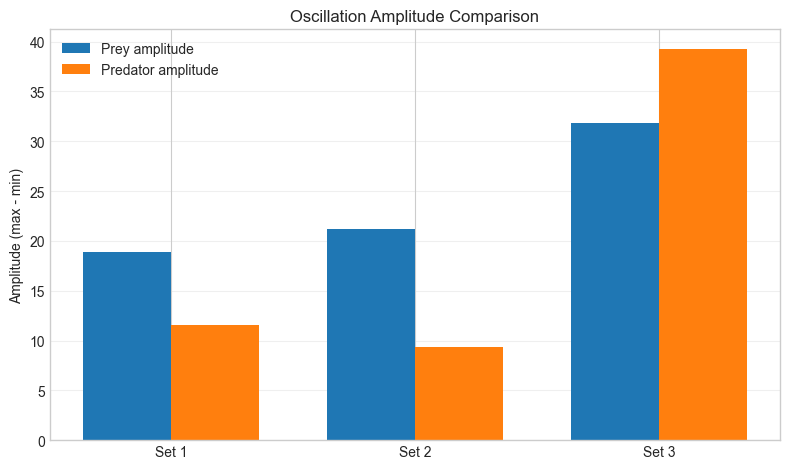

In [6]:
def oscillation_amplitude(series, keep_fraction=0.4):
    start = int((1.0 - keep_fraction) * len(series))
    w = series[start:]
    return float(np.max(w) - np.min(w))

amp_rows = []
for p in parameter_sets:
    name = p['name']
    sol = results[name]
    amp_x = oscillation_amplitude(sol[:, 0])
    amp_y = oscillation_amplitude(sol[:, 1])
    x_star_i, y_star_i = coexistence_equilibrium(**{k: v for k, v in p.items() if k != 'name'})
    amp_rows.append((name, x_star_i, y_star_i, amp_x, amp_y))

print('Summary of equilibria and oscillation amplitudes (computed from last 40% of trajectory):')
for name, x_star_i, y_star_i, amp_x, amp_y in amp_rows:
    print(
        f"{name:5s} | x* = {x_star_i:6.3f} | y* = {y_star_i:6.3f} "
        f"| prey amp = {amp_x:8.3f} | predator amp = {amp_y:8.3f}"
    )

labels = [r[0] for r in amp_rows]
prey_amps = [r[3] for r in amp_rows]
pred_amps = [r[4] for r in amp_rows]
idx = np.arange(len(labels))
w = 0.36

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(idx - w / 2, prey_amps, width=w, label='Prey amplitude')
ax.bar(idx + w / 2, pred_amps, width=w, label='Predator amplitude')
ax.set_xticks(idx)
ax.set_xticklabels(labels)
ax.set_ylabel('Amplitude (max - min)')
ax.set_title('Oscillation Amplitude Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Analysis Q1-Q2
1. **How does reducing alpha affect predator population?**  \n   Pada model dasar, penurunan $\alpha$ memperlambat pemulihan prey setelah dipredasi. Secara analitik, $x^* = \gamma/\delta$ tidak berubah karena tidak bergantung pada $\alpha$, sedangkan $y^* = \alpha/\beta$ turun secara linear saat $\alpha$ diturunkan. Simulasi menunjukkan konsekuensi biologis yang konsisten: level rata-rata predator lebih rendah dan osilasi predator cenderung mengecil karena suplai prey berkurang.

2. **What happens to x* = gamma/delta when delta doubles?**  \n   Karena $x^* = \gamma/\delta$, jika $\delta$ menjadi $2\delta$ maka
   $$x^*_{\mathrm{baru}} = \frac{\gamma}{2\delta} = \frac{1}{2}x^*_{\mathrm{lama}}.$$
   Jadi, populasi prey pada ekuilibrium non-trivial menjadi setengah dari nilai semula.


### 7. Studi Hunting Term (-H)
Menambahkan komponen panen/perburuan `-H` pada persamaan prey, lalu membandingkan perubahan time-series dan titik ko-eksistensi.


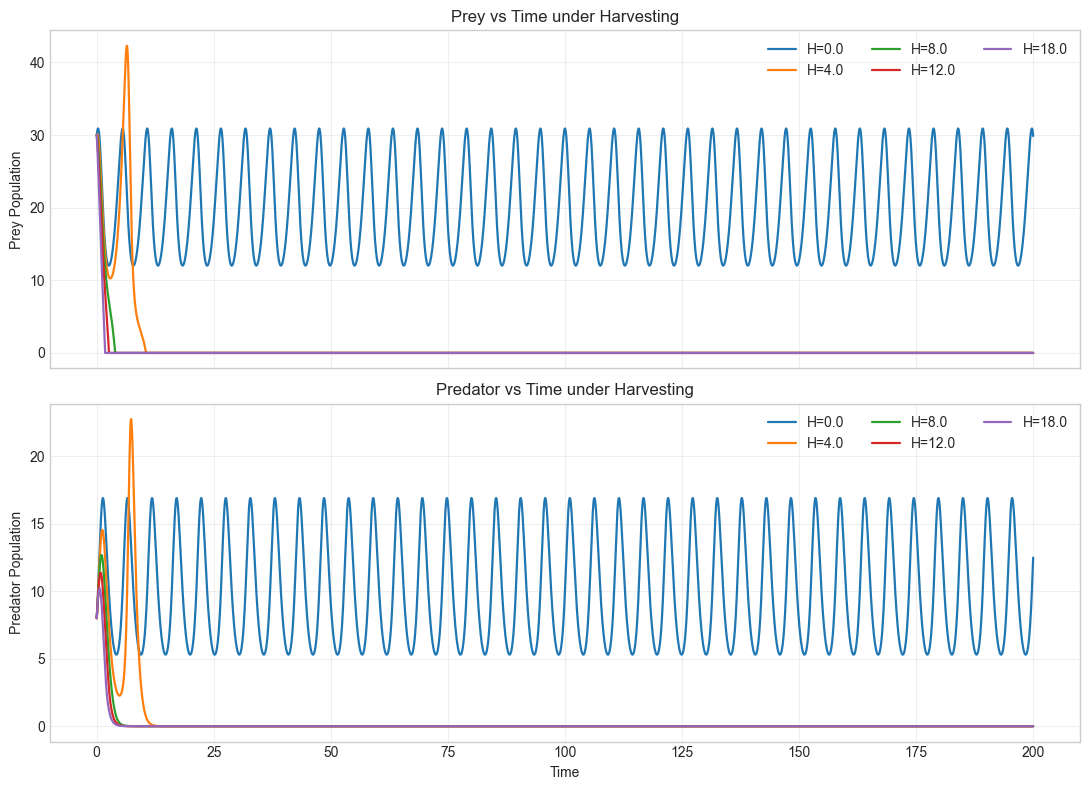

Critical harvesting threshold for positive predator equilibrium: H < 20.000
H= 0.0 -> coexistence equilibrium: x*=20.000, y*=10.000 (biologically feasible)
H= 4.0 -> coexistence equilibrium: x*=20.000, y*=8.000 (biologically feasible)
H= 8.0 -> coexistence equilibrium: x*=20.000, y*=6.000 (biologically feasible)
H=12.0 -> coexistence equilibrium: x*=20.000, y*=4.000 (biologically feasible)
H=18.0 -> coexistence equilibrium: x*=20.000, y*=1.000 (biologically feasible)


In [7]:
# Hunting term study: dx/dt = alpha*x - beta*x*y - H
harvest_levels = [0.0, 4.0, 8.0, 12.0, 18.0]
harvest_solutions = {}
base_params = {k: v for k, v in set1.items() if k != 'name'}

for H in harvest_levels:
    params = dict(base_params)
    params['H'] = H
    harvest_solutions[H] = rk4_integrate(lotka_volterra_rhs, np.array([x0, y0]), t, **params)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for H in harvest_levels:
    sol = harvest_solutions[H]
    axes[0].plot(t, sol[:, 0], linewidth=1.6, label=f'H={H}')
    axes[1].plot(t, sol[:, 1], linewidth=1.6, label=f'H={H}')

axes[0].set_title('Prey vs Time under Harvesting')
axes[0].set_ylabel('Prey Population')
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.3)

axes[1].set_title('Predator vs Time under Harvesting')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Predator Population')
axes[1].legend(ncol=3)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

x_star_h = set1['gamma'] / set1['delta']
H_crit = set1['alpha'] * x_star_h
print(f'Critical harvesting threshold for positive predator equilibrium: H < {H_crit:.3f}')
for H in harvest_levels:
    x_star_h, y_star_h = coexistence_equilibrium(**base_params, H=H)
    feasible = 'biologically feasible' if y_star_h > 0 else 'predator collapses at equilibrium'
    print(
        f"H={H:>4.1f} -> coexistence equilibrium: x*={x_star_h:.3f}, "
        f"y*={y_star_h:.3f} ({feasible})"
    )


### Analysis Q3-Q4
3. **What changes after adding hunting term -H in prey equation?**  \n   Penambahan suku $-H$ menurunkan prey secara konstan, sehingga level prey menurun dan sistem terdorong ke ko-eksistensi yang berbeda. Dari syarat ekuilibrium,
   $$0 = \delta x^* y^* - \gamma y^* \Rightarrow x^* = \frac{\gamma}{\delta},$$
   dan substitusi ke persamaan prey memberi
   $$0 = \alpha x^* - \beta x^* y^* - H \Rightarrow y^* = \frac{\alpha x^* - H}{\beta x^*} = \frac{\alpha}{\beta} - \frac{H\delta}{\beta\gamma}.$$
   Jadi, $x^*$ tetap, tetapi $y^*$ turun linear terhadap $H$. Syarat biologis untuk ko-eksistensi predator adalah $y^* > 0$, ekuivalen dengan $H < \alpha\gamma/\delta$.

4. **Connection to Volterra's fishing paradox**  \n   Secara kualitatif, hasil ini terhubung dengan paradoks perikanan Volterra: intervensi eksternal pada sistem predator-prey dapat menghasilkan respons yang tidak intuitif terhadap amplitudo maupun level populasi. Pada notebook ini, harvesting hanya diterapkan pada prey, sehingga model ini bukan reproduksi persis paradoks Volterra klasik. Namun, simulasi tetap menunjukkan ide utamanya, yaitu bahwa tekanan antropogenik dapat mengubah relasi trofik dan menimbulkan perubahan besar pada predator, meskipun intervensi langsung diberikan pada prey.
